# Mackey-Glass Time Series

## Background

The **Mackey-Glass (MG) equation** is a nonlinear delay differential equation (DDE) originally proposed by Michael Mackey and Leon Glass (1977) to model physiological control systems. It is the **de facto standard benchmark for reservoir computing**, used in virtually every QRC paper including:

- Fujii & Nakajima (2020) — *QRC for near-term quantum devices*
- Nakajima (2019) — *Spatial multiplexing QRC*
- Ghosh et al. (2019) — *Quantum reservoir processing*
- Mujal et al. (2023) — *Time series prediction with QRC*

## The Equation

$$\frac{dx(t)}{dt} = \frac{\beta \, x(t-\tau)}{1 + x(t-\tau)^n} - \gamma \, x(t)$$

| Parameter | Typical value | Effect |
|-----------|--------------|--------|
| beta      | 0.2          | Production rate |
| gamma     | 0.1          | Decay rate |
| n         | 10           | Nonlinearity exponent |
| tau       | 17           | Time delay -- controls chaos level |

- tau=17: **weakly chaotic** -- used in most RC benchmarks
- tau=30: **strongly chaotic** -- harder prediction task

## Why it is ideal for QRC

1. **Long memory**: the delay tau means the system depends on past states, exactly what a reservoir's fading memory must capture
2. **Tunable complexity**: change tau to sweep from periodic to chaotic
3. **Well-studied**: published NRMSE benchmarks exist for classical ESN and QRC, enabling direct comparison
4. **Standard task**: predict x(t+P) from x(t), typically P=1 (one-step-ahead) or P=84 (multi-step)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(42)

## Numerical Integration

DDEs cannot be solved with standard ODE solvers -- we track the history x(t-tau) using a circular buffer and integrate with Euler steps.

In [2]:
def mackey_glass(T=10000, tau=17, beta=0.2, gamma=0.1, n=10, dt=1.0, x0=1.2, washout=500):
    """
    Generate a Mackey-Glass time series using Euler integration with circular history buffer.

    Parameters
    ----------
    T       : total steps to generate (after washout)
    tau     : delay in timesteps (17 = weakly chaotic, 30 = strongly chaotic)
    beta    : production rate
    gamma   : decay rate
    n       : nonlinearity exponent
    dt      : integration step size
    x0      : initial condition
    washout : initial transient steps to discard

    Returns
    -------
    np.ndarray of shape (T,)
    """
    history_len = tau + 1
    history = np.full(history_len, x0, dtype=float)
    total_steps = T + washout
    x_all = np.empty(total_steps)
    x_all[0] = x0
    x_current = x0
    for i in range(1, total_steps):
        x_delayed = history[i % history_len]
        dxdt = beta * x_delayed / (1.0 + x_delayed ** n) - gamma * x_current
        x_current = x_current + dt * dxdt
        history[i % history_len] = x_current
        x_all[i] = x_current
    return x_all[washout:]

In [3]:
mg17 = mackey_glass(T=10000, tau=17)
mg30 = mackey_glass(T=10000, tau=30)

print(f'Shape: {mg17.shape}')
print(f'MG-17  min={mg17.min():.4f}  max={mg17.max():.4f}  mean={mg17.mean():.4f}')
print(f'MG-30  min={mg30.min():.4f}  max={mg30.max():.4f}  mean={mg30.mean():.4f}')

Shape: (10000,)
MG-17  min=0.3696  max=1.3436  mean=0.9258
MG-30  min=0.2092  max=1.3892  mean=0.8904


## Visualisation

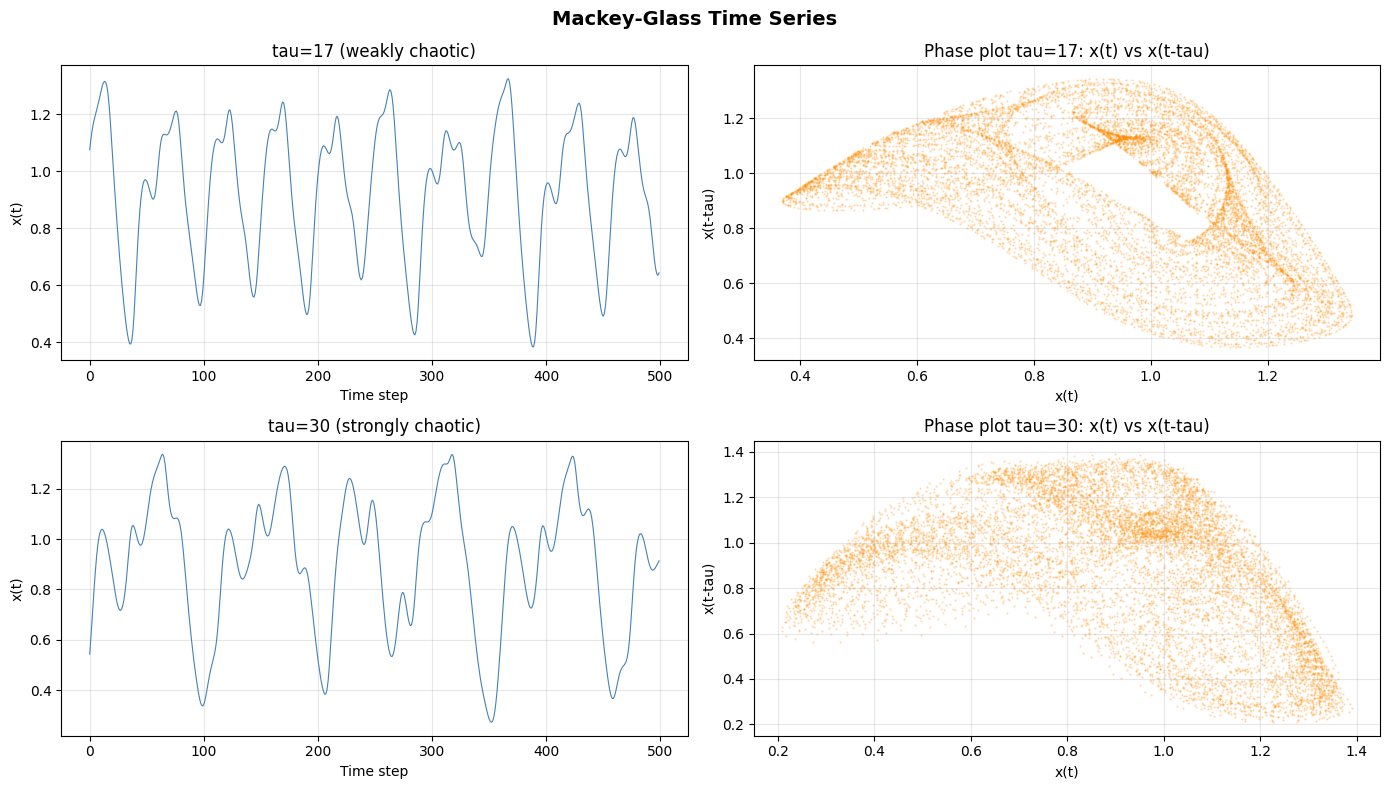

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Mackey-Glass Time Series', fontsize=14, fontweight='bold')

for ax, data, label in zip(axes[:, 0], [mg17, mg30], ['tau=17 (weakly chaotic)', 'tau=30 (strongly chaotic)']):
    ax.plot(data[:500], lw=0.8, color='steelblue')
    ax.set_title(label)
    ax.set_xlabel('Time step')
    ax.set_ylabel('x(t)')
    ax.grid(True, alpha=0.3)

for ax, data, tau, label in zip(axes[:, 1], [mg17, mg30], [17, 30], ['tau=17', 'tau=30']):
    ax.scatter(data[:-tau], data[tau:], s=0.3, alpha=0.3, color='darkorange')
    ax.set_title(f'Phase plot {label}: x(t) vs x(t-tau)')
    ax.set_xlabel('x(t)')
    ax.set_ylabel('x(t-tau)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mackey_glass_plots.png', dpi=150, bbox_inches='tight')
plt.show()

## Train / Validation / Test Split

Standard split used in QRC literature:

| Split | Steps | Purpose |
|-------|-------|--------|
| Train | 5000  | Fit readout weights |
| Val   | 1000  | Hyperparameter selection |
| Test  | 2000  | Final NRMSE evaluation |

In [5]:
def make_prediction_pairs(series, horizon=1):
    """Build (input, target) pairs: target is x(t + horizon) given input x(t)."""
    return series[:-horizon], series[horizon:]


TRAIN, VAL, TEST, HORIZON = 5000, 1000, 2000, 1

X_all, y_all = make_prediction_pairs(mg17, horizon=HORIZON)
X_train, y_train = X_all[:TRAIN], y_all[:TRAIN]
X_val,   y_val   = X_all[TRAIN:TRAIN+VAL], y_all[TRAIN:TRAIN+VAL]
X_test,  y_test  = X_all[TRAIN+VAL:TRAIN+VAL+TEST], y_all[TRAIN+VAL:TRAIN+VAL+TEST]

print(f'Train: {X_train.shape}  |  Val: {X_val.shape}  |  Test: {X_test.shape}')

Train: (5000,)  |  Val: (1000,)  |  Test: (2000,)


## Evaluation Metric: NRMSE

Standard metric in QRC papers:

NRMSE = sqrt( mean((y_pred - y_true)^2) / var(y_true) )

- NRMSE = 0 : perfect prediction
- NRMSE = 1 : predicting the mean (trivial baseline)
- Published QRC results: NRMSE ~0.005-0.05 for MG-17 horizon-1

In [6]:
def nrmse(y_true, y_pred):
    """Normalised Root Mean Square Error."""
    return float(np.sqrt(np.mean((y_pred - y_true) ** 2) / np.var(y_true)))

nrmse_naive = nrmse(y_test, X_test)
print(f'Naive baseline NRMSE (predict x(t) for x(t+1)): {nrmse_naive:.4f}')
print('A good QRC model should achieve NRMSE well below this value.')

Naive baseline NRMSE (predict x(t) for x(t+1)): 0.1460
A good QRC model should achieve NRMSE well below this value.


## Save Datasets to CSV

In [7]:
pd.DataFrame({'x': mg17}).to_csv('mackey_glass_tau17.csv', index_label='t')
pd.DataFrame({'x': mg30}).to_csv('mackey_glass_tau30.csv', index_label='t')

for name, X, y in [('train', X_train, y_train), ('val', X_val, y_val), ('test', X_test, y_test)]:
    pd.DataFrame({'x_t': X, 'x_t1': y}).to_csv(f'mackey_glass_tau17_{name}.csv', index=False)

print('Saved: mackey_glass_tau17.csv, mackey_glass_tau30.csv')
print('Saved: mackey_glass_tau17_train/val/test.csv')

Saved: mackey_glass_tau17.csv, mackey_glass_tau30.csv
Saved: mackey_glass_tau17_train/val/test.csv


## Using This Dataset in QRC

Minimal QRC loop (pseudocode):

```python
for t, u_t in enumerate(X_train):
    rho = encode(u_t, n_qubits=N)         # encode scalar input
    rho = reservoir_evolve(rho)            # fixed quantum dynamics
    features[t] = measure(rho)            # e.g. <sigma_z^i> for each qubit

# Train only the linear readout
W_out = ridge_regression(features, y_train, alpha=1e-6)

y_pred = features_test @ W_out
print(nrmse(y_test, y_pred))
```

Key references for MG benchmarks in your collection:
- Fujii & Nakajima (2020): Table 1 -- NRMSE for QRC vs classical ESN on MG-17
- Nakajima (2019): spatial multiplexing QRC on MG series
- Ghosh et al. (2019): quantum reservoir processing with MG
- Mujal et al. (2023): weak measurement QRC on MG